In [ ]:
!rm -rf /content/drive
!mkdir /content/drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'DR_New_Results', 'Dataset']


In [ ]:
# checkpoint_path defined here; actual load runs after model init
checkpoint_path = "/content/drive/MyDrive/checkpoint.pth"
start_epoch = 0
# Actual loading happens in the post-model cell below

In [ ]:
!pip install timm imbalanced-learn
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import cohen_kappa_score
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
import timm
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import cv2
import matplotlib.cm as cm

In [ ]:
import os

# =========================
# PATHS
# =========================
USE_DRIVE = True   # 🔥 Change to False if you don't want Drive

if USE_DRIVE:
    RESULT_PATH = "/content/drive/MyDrive/DR_New_Results/IDRiD"
else:
    RESULT_PATH = "/content/DR_New_Results/IDRiD"

# =========================
# CREATE FOLDER
# =========================
os.makedirs(RESULT_PATH, exist_ok=True)

print("Saving results at:", RESULT_PATH)

Saving results at: /content/drive/MyDrive/DR_New_Results/IDRiD


**Reproducibility and Seed Configuration**

In [ ]:
import random
import os
import numpy as np
import torch

# =========================
# SET RANDOM SEED
# =========================
def set_seed(seed=42):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed(seed)

        torch.cuda.manual_seed_all(seed)

    os.environ['PYTHONHASHSEED'] = str(seed)

    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False

# =========================
# APPLY SEED
# =========================
set_seed(42)

**IDRiD Dataset Loading and Balancing**

In [ ]:
# =========================
# LOAD AND BALANCE IDRID DATASET
# =========================

# =========================
# DATASET PATHS
# =========================
idrid_root = "/content/drive/MyDrive/Dataset/IDRiD/Train"

csv_path = os.path.join(
    idrid_root,
    "annotations.csv"
)

image_folder = os.path.join(
    idrid_root,
    "images"
)

# =========================
# LOAD CSV FILE
# =========================
idrid_df = pd.read_csv(csv_path)

idrid_df.rename(
    columns={
        "Retinopathy grade": "label"
    },
    inplace=True
)

# =========================
# BUILD IMAGE DICTIONARY
# =========================
image_dict = {}

for file in os.listdir(image_folder):

    if file.lower().endswith(
        (".jpg", ".png", ".jpeg")
    ):

        key = os.path.splitext(file)[0] \
            .strip() \
            .lower()

        image_dict[key] = os.path.join(
            image_folder,
            file
        )

# =========================
# FIND IMAGE FUNCTION
# =========================
def find_image(name):

    name = str(name) \
        .strip() \
        .lower()

    name = os.path.splitext(name)[0]

    return image_dict.get(
        name,
        None
    )

# =========================
# MAP IMAGE PATHS
# =========================
idrid_df["image_path"] = idrid_df[
    "Image name"
].apply(find_image)

# =========================
# REMOVE MISSING IMAGES
# =========================
idrid_df = idrid_df.dropna(
    subset=["image_path"]
).reset_index(drop=True)

print(
    "Dataset loaded:",
    len(idrid_df)
)

print(
    "\nBefore Balancing:\n",
    idrid_df["label"].value_counts()
)

# =========================
# BALANCE DATASET
# =========================
ros = RandomOverSampler(
    random_state=42
)

X_res, y_res = ros.fit_resample(

    idrid_df[["image_path"]],

    idrid_df["label"]
)

idrid_balanced_df = pd.DataFrame({

    "image_path": X_res["image_path"],

    "label": y_res
})

# =========================
# ADD IMAGE NAMES
# =========================
idrid_balanced_df["Image name"] = \
    idrid_balanced_df["image_path"].apply(
        os.path.basename
    )

print(
    "\nAfter Balancing:\n",
    idrid_balanced_df["label"].value_counts()
)

# =========================
# TRAIN / VALIDATION SPLIT
# =========================
train_df, val_df = train_test_split(

    idrid_balanced_df,

    test_size=0.2,

    stratify=idrid_balanced_df["label"],

    random_state=42
)

print("\nTrain size:", len(train_df))

print("Validation size:", len(val_df))

Dataset loaded: 1239

Before Balancing:
 label
2    408
0    402
3    222
4    147
1     60
Name: count, dtype: int64

After Balancing:
 label
0    408
1    408
2    408
3    408
4    408
Name: count, dtype: int64

Train size: 1632
Validation size: 408


**IDRID DATA DISTRIBUTION VISUALIZATION**

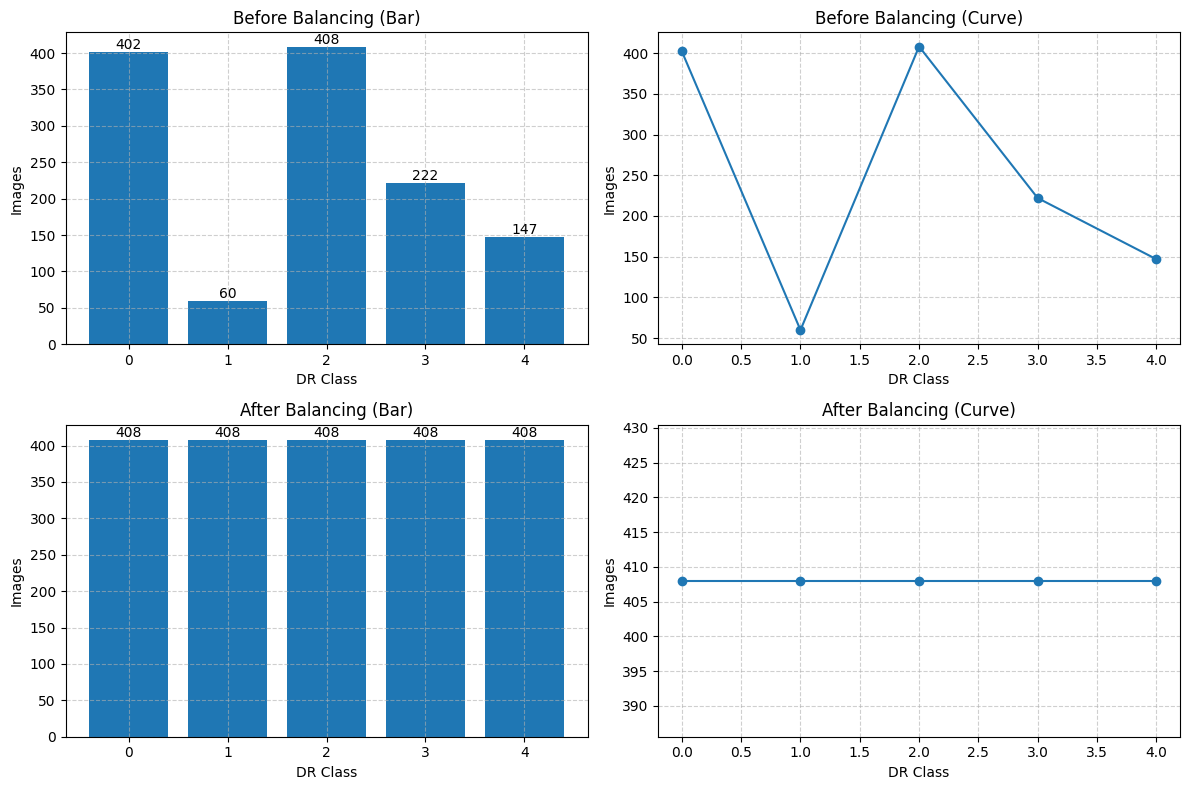


Saved at: /content/drive/MyDrive/DR_New_Results/IDRiD/idrid_before_after_balancing.png


In [ ]:

# =========================
# CLASS DISTRIBUTION COUNTS
# =========================
before_counts = idrid_df[
    "label"
].value_counts().sort_index()

after_counts = idrid_balanced_df[
    "label"
].value_counts().sort_index()

# =========================
# ADD VALUE LABELS
# =========================
def add_labels(ax):

    for p in ax.patches:

        height = p.get_height()

        ax.annotate(
            f'{int(height)}',
            (
                p.get_x() + p.get_width()/2,
                height
            ),
            ha='center',
            va='bottom',
            fontsize=10
        )

# =========================
# APPLY COMMON STYLING
# =========================
def style_plot(ax, title):

    ax.set_title(title)

    ax.set_xlabel("DR Class")

    ax.set_ylabel("Images")

    ax.grid(
        True,
        linestyle='--',
        alpha=0.6
    )

# =========================
# CREATE VISUALIZATION
# =========================
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12,8)
)

# =========================
# BEFORE BALANCING
# =========================
axes[0,0].bar(
    before_counts.index,
    before_counts.values
)

add_labels(axes[0,0])

style_plot(
    axes[0,0],
    "Before Balancing (Bar)"
)

axes[0,1].plot(
    before_counts.index,
    before_counts.values,
    marker='o'
)

style_plot(
    axes[0,1],
    "Before Balancing (Curve)"
)

# =========================
# AFTER BALANCING
# =========================
axes[1,0].bar(
    after_counts.index,
    after_counts.values
)

add_labels(axes[1,0])

style_plot(
    axes[1,0],
    "After Balancing (Bar)"
)

axes[1,1].plot(
    after_counts.index,
    after_counts.values,
    marker='o'
)

style_plot(
    axes[1,1],
    "After Balancing (Curve)"
)

plt.tight_layout()

# =========================
# SAVE VISUALIZATION
# =========================
save_dir = (
    "/content/drive/MyDrive/"
    "DR_New_Results/IDRiD"
)

os.makedirs(
    save_dir,
    exist_ok=True
)

save_path = os.path.join(
    save_dir,
    "idrid_before_after_balancing.png"
)

plt.savefig(
    save_path,
    dpi=300
)

plt.show()

# =========================
# DISPLAY SAVE MESSAGE
# =========================
print(f"\nSaved at: {save_path}")

**Balanced Data Visualization**

Validation size: 204
Test size: 204


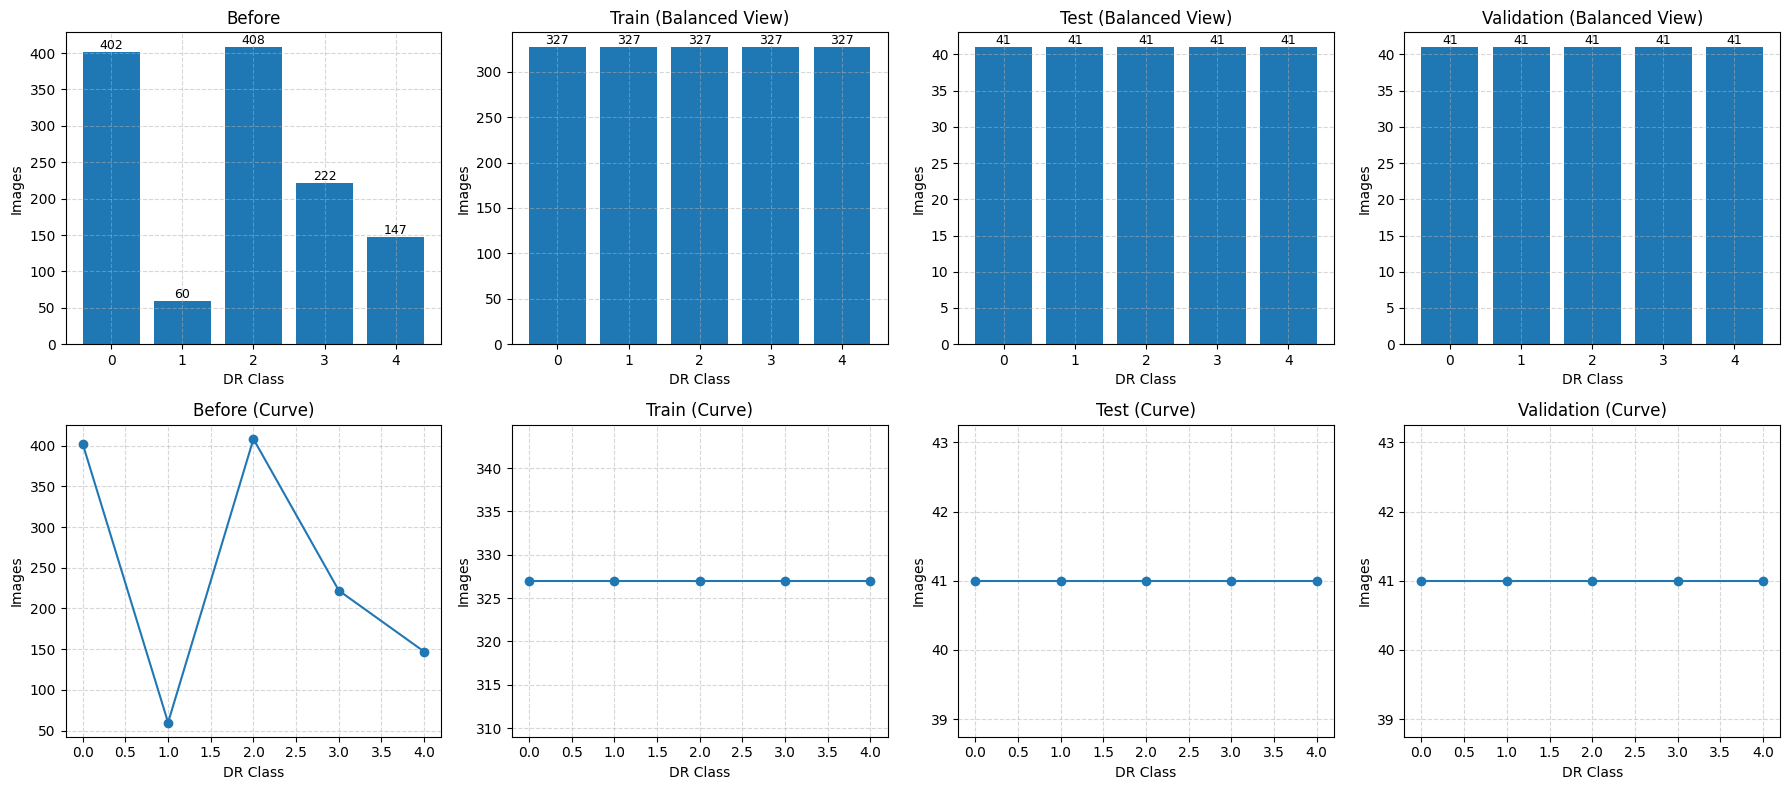


Saved at: /content/drive/MyDrive/DR_New_Results/IDRiD/balanced_visual_only.png


In [ ]:


# =========================
# BALANCE FUNCTION
# =========================
def balance_for_plot(df):

    ros = RandomOverSampler(
        random_state=42
    )

    X_res, y_res = ros.fit_resample(

        df[["image_path"]],

        df["label"]
    )

    return pd.DataFrame({

        "image_path": X_res["image_path"],

        "label": y_res
    })

# =========================
# CREATE TEST SET IF MISSING
# =========================
if 'test_df' not in globals():

    val_df_original = val_df.copy()

    val_df, test_df = train_test_split(

        val_df_original,

        test_size=0.5,

        stratify=val_df_original["label"],

        random_state=42
    )

    print(
        "WARNING: test_df was created "
        "from val_df for visualization."
    )

    print(
        f"Validation size: {len(val_df)}"
    )

    print(
        f"Test size: {len(test_df)}"
    )

# =========================
# CREATE BALANCED DATA
# =========================
train_bal_plot = balance_for_plot(
    train_df
)

val_bal_plot = balance_for_plot(
    val_df
)

test_bal_plot = balance_for_plot(
    test_df
)

# =========================
# COMPUTE COUNTS
# =========================
before_counts = idrid_df[
    "label"
].value_counts().sort_index()

train_counts = train_bal_plot[
    "label"
].value_counts().sort_index()

test_counts = test_bal_plot[
    "label"
].value_counts().sort_index()

val_counts = val_bal_plot[
    "label"
].value_counts().sort_index()

# =========================
# ADD VALUE LABELS
# =========================
def add_labels(ax):

    for p in ax.patches:

        height = p.get_height()

        ax.annotate(
            f'{int(height)}',
            (
                p.get_x() + p.get_width()/2,
                height
            ),
            ha='center',
            va='bottom',
            fontsize=9
        )

# =========================
# APPLY COMMON STYLING
# =========================
def style_plot(ax, title):

    ax.set_title(title)

    ax.set_xlabel("DR Class")

    ax.set_ylabel("Images")

    ax.grid(
        True,
        linestyle='--',
        alpha=0.5
    )

# =========================
# CREATE VISUALIZATION
# =========================
fig, axes = plt.subplots(
    2,
    4,
    figsize=(18,8)
)

# =========================
# BAR PLOTS
# =========================
bar_data = [

    (before_counts, "Before"),

    (train_counts, "Train (Balanced View)"),

    (test_counts, "Test (Balanced View)"),

    (val_counts, "Validation (Balanced View)")
]

for idx, (counts, title) in enumerate(bar_data):

    axes[0, idx].bar(
        counts.index,
        counts.values
    )

    add_labels(
        axes[0, idx]
    )

    style_plot(
        axes[0, idx],
        title
    )

# =========================
# CURVE PLOTS
# =========================
curve_data = [

    (before_counts, "Before (Curve)"),

    (train_counts, "Train (Curve)"),

    (test_counts, "Test (Curve)"),

    (val_counts, "Validation (Curve)")
]

for idx, (counts, title) in enumerate(curve_data):

    axes[1, idx].plot(
        counts.index,
        counts.values,
        marker='o'
    )

    style_plot(
        axes[1, idx],
        title
    )

plt.tight_layout()

# =========================
# SAVE VISUALIZATION
# =========================
save_dir = (
    "/content/drive/MyDrive/"
    "DR_New_Results/IDRiD"
)

os.makedirs(
    save_dir,
    exist_ok=True
)

save_path = os.path.join(
    save_dir,
    "balanced_visual_only.png"
)

plt.savefig(
    save_path,
    dpi=300
)

plt.show()

# =========================
# DISPLAY SAVE MESSAGE
# =========================
print(f"\nSaved at: {save_path}")

**Balanced Split Visualization**

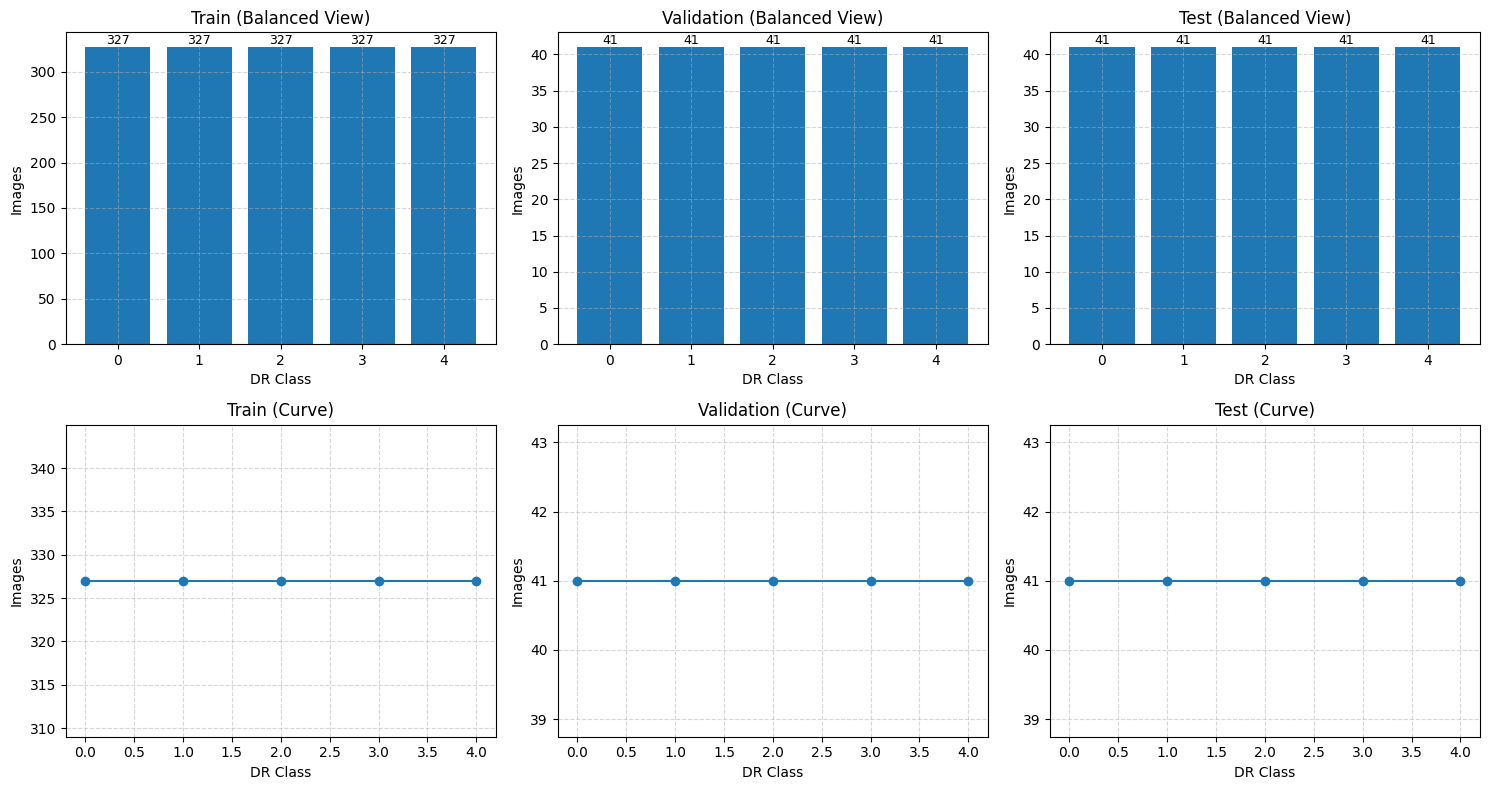


Balanced visual saved at: /content/drive/MyDrive/DR_New_Results/IDRiD/final_split_balanced_visual.png


In [ ]:
# =========================
# BALANCED SPLIT VISUALIZATION
# =========================

# =========================
# BALANCE FUNCTION
# =========================
def balance_for_plot(df):

    ros = RandomOverSampler(
        random_state=42
    )

    X_res, y_res = ros.fit_resample(

        df[["image_path"]],

        df["label"]
    )

    return pd.DataFrame({

        "image_path": X_res["image_path"],

        "label": y_res
    })

# =========================
# CREATE BALANCED DATA
# =========================
train_bal = balance_for_plot(
    train_df
)

val_bal = balance_for_plot(
    val_df
)

test_bal = balance_for_plot(
    test_df
)

# =========================
# COMPUTE COUNTS
# =========================
train_bal_counts = train_bal[
    "label"
].value_counts().sort_index()

val_bal_counts = val_bal[
    "label"
].value_counts().sort_index()

test_bal_counts = test_bal[
    "label"
].value_counts().sort_index()

# =========================
# APPLY COMMON STYLING
# =========================
def style_plot(ax, title):

    ax.set_title(title)

    ax.set_xlabel("DR Class")

    ax.set_ylabel("Images")

    ax.grid(
        True,
        linestyle='--',
        alpha=0.5
    )

# =========================
# CREATE VISUALIZATION
# =========================
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15,8)
)

# =========================
# BAR PLOTS
# =========================
bar_data = [

    (train_bal_counts, "Train (Balanced View)"),

    (val_bal_counts, "Validation (Balanced View)"),

    (test_bal_counts, "Test (Balanced View)")
]

for idx, (counts, title) in enumerate(bar_data):

    axes[0, idx].bar(
        counts.index,
        counts.values
    )

    add_labels(
        axes[0, idx]
    )

    style_plot(
        axes[0, idx],
        title
    )

# =========================
# CURVE PLOTS
# =========================
curve_data = [

    (train_bal_counts, "Train (Curve)"),

    (val_bal_counts, "Validation (Curve)"),

    (test_bal_counts, "Test (Curve)")
]

for idx, (counts, title) in enumerate(curve_data):

    axes[1, idx].plot(
        counts.index,
        counts.values,
        marker='o'
    )

    style_plot(
        axes[1, idx],
        title
    )

plt.tight_layout()

# =========================
# SAVE VISUALIZATION
# =========================
save_path_bal = (
    "/content/drive/MyDrive/"
    "DR_New_Results/IDRiD/"
    "final_split_balanced_visual.png"
)

plt.savefig(
    save_path_bal,
    dpi=300
)

plt.show()

# =========================
# DISPLAY SAVE MESSAGE
# =========================
print(
    f"\nBalanced visual saved at: "
    f"{save_path_bal}"
)

**Data Augmentation and Preprocessing Pipeline**

In [ ]:
# =========================
# DUAL ATTENTION DR MODEL
# DENSENET201 VERSION
# =========================

class DualAttentionDRModel(nn.Module):

    def __init__(self, num_classes=5):

        super().__init__()

        # =========================
        # DENSENET201 BACKBONE
        # =========================
        self.backbone = timm.create_model(

            'densenet201',

            pretrained=True,

            features_only=True
        )

        # =========================
        # GET FEATURE CHANNELS
        # =========================
        ch = self.backbone.feature_info[-1]['num_chs']

        # =========================
        # ATTENTION MODULE
        # =========================
        self.attention = nn.Sequential(

            nn.Conv2d(
                ch,
                ch,
                kernel_size=1
            ),

            nn.ReLU(),

            nn.Conv2d(
                ch,
                ch,
                kernel_size=1
            ),

            nn.Sigmoid()
        )

        # =========================
        # GLOBAL POOLING
        # =========================
        self.pool = nn.AdaptiveAvgPool2d(1)

        # =========================
        # CLASSIFIER
        # =========================
        self.classifier = nn.Linear(
            ch,
            num_classes
        )

    def forward(self, x):

        # =========================
        # FEATURE EXTRACTION
        # =========================
        x = self.backbone(x)[-1]

        # =========================
        # APPLY ATTENTION
        # =========================
        x = x * self.attention(x)

        # =========================
        # GLOBAL POOLING
        # =========================
        x = self.pool(x).flatten(1)

        # =========================
        # CLASSIFICATION
        # =========================
        x = self.classifier(x)

        return x

**DR Dataset Class**

In [ ]:
# =========================
# DR DATASET CLASS
# =========================
class DRDataset(Dataset):

    def __init__(self, df, transform=None):

        self.transform = transform

        # =========================
        # FILTER VALID FILES
        # =========================
        self.df = df[
            df["image_path"].apply(
                os.path.exists
            )
        ].reset_index(drop=True)

        print(
            f"Valid images: {len(self.df)}"
        )

    # =========================
    # DATASET LENGTH
    # =========================
    def __len__(self):

        return len(self.df)

    # =========================
    # LOAD SAMPLE
    # =========================
    def __getitem__(self, idx):

        img_path = self.df.loc[
            idx,
            "image_path"
        ]

        label = int(
            self.df.loc[idx, "label"]
        )

        # =========================
        # SAFE IMAGE LOADING
        # =========================
        try:

            image = Image.open(
                img_path
            ).convert("RGB")

        except Exception:

            print(
                f"Error loading: {img_path}"
            )

            image = Image.new(
                "RGB",
                (320, 320)
            )

        # =========================
        # APPLY TRANSFORM
        # =========================
        if self.transform:

            image = self.transform(
                image
            )

        return (

            image,

            torch.tensor(
                label,
                dtype=torch.long
            )
        )

In [ ]:
train_dataset = DRDataset(train_df, transform=train_transform)
val_dataset   = DRDataset(val_df, transform=val_transform)
test_dataset  = DRDataset(test_df, transform=val_transform)

Valid images: 1632
Valid images: 204
Valid images: 204


**Training, Validation, and Test DataLoader Setup**

In [ ]:
# =========================
# DEVICE CONFIGURATION
# =========================
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

# =========================
# DATALOADER SETTINGS
# =========================
if device.type == "cuda":

    # 🔥 Reduced for DenseNet201
    batch_size = 8

    num_workers = 2

    pin_memory = True

else:

    batch_size = 4

    num_workers = 0

    pin_memory = False

persistent_workers = (
    num_workers > 0
)

# =========================
# COMMON LOADER SETTINGS
# =========================
loader_kwargs = dict(

    batch_size=batch_size,

    num_workers=num_workers,

    pin_memory=pin_memory,

    persistent_workers=persistent_workers
)

# =========================
# TRAIN LOADER
# =========================
train_loader = DataLoader(

    train_dataset,

    shuffle=True,

    drop_last=True,

    **loader_kwargs
)

# =========================
# VALIDATION LOADER
# =========================
val_loader = DataLoader(

    val_dataset,

    shuffle=False,

    **loader_kwargs
)

# =========================
# TEST LOADER
# =========================
test_loader = DataLoader(

    test_dataset,

    shuffle=False,

    **loader_kwargs
)

**Proposed Model Architecture**

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import (
    densenet201,
    DenseNet201_Weights
)

# =========================
# CROSS PATCH ATTENTION
# =========================
class CrossPatchAttention(nn.Module):

    def __init__(self, in_channels):

        super().__init__()

        reduced_channels = max(
            in_channels // 8,
            1
        )

        self.query = nn.Conv2d(
            in_channels,
            reduced_channels,
            1
        )

        self.key = nn.Conv2d(
            in_channels,
            reduced_channels,
            1
        )

        self.value = nn.Conv2d(
            in_channels,
            in_channels,
            1
        )

        self.gamma = nn.Parameter(
            torch.zeros(1)
        )

    def forward(self, x):

        B, C, H, W = x.shape

        q = self.query(x).flatten(2)

        k = self.key(x).flatten(2)

        v = self.value(x).flatten(2)

        # =========================
        # SCALED ATTENTION
        # =========================
        attn = torch.bmm(

            q.transpose(1, 2),

            k

        ) / (C ** 0.5)

        attn = torch.softmax(
            attn,
            dim=-1
        )

        out = torch.bmm(

            v,

            attn.transpose(1, 2)
        )

        out = out.view(
            B,
            C,
            H,
            W
        )

        return (
            self.gamma * out
            + x
        )

# =========================
# REGION ATTENTION
# =========================
class RegionAttention(nn.Module):

    def __init__(self, in_channels):

        super().__init__()

        reduced_channels = max(
            in_channels // 4,
            1
        )

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                reduced_channels,
                3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                reduced_channels,
                in_channels,
                1
            ),

            nn.Sigmoid()
        )

    def forward(self, x):

        return x * self.conv(x)

# =========================
# FINAL DR MODEL
# DENSENET201 VERSION
# =========================
class DRModel(nn.Module):

    def __init__(self, num_classes=5):

        super().__init__()

        # =========================
        # DENSENET201 BACKBONE
        # =========================
        backbone = densenet201(
            weights=DenseNet201_Weights.IMAGENET1K_V1
        )

        self.features = backbone.features

        # =========================
        # DENSENET201 OUTPUT CHANNELS
        # =========================
        in_channels = 1920

        # =========================
        # FREEZE EARLY BLOCKS
        # =========================
        for param in list(
            self.features.parameters()
        )[:50]:

            param.requires_grad = False

        # =========================
        # ATTENTION MODULES
        # =========================
        self.cross_attention = CrossPatchAttention(
            in_channels
        )

        self.region_attention = RegionAttention(
            in_channels
        )

        # =========================
        # FEATURE PROCESSING
        # =========================
        self.feat_drop = nn.Dropout2d(0.15)

        self.pool = nn.AdaptiveAvgPool2d(1)

        # =========================
        # CLASSIFIER HEAD
        # =========================
        self.head = nn.Sequential(

            nn.BatchNorm1d(
                in_channels
            ),

            nn.Linear(
                in_channels,
                512
            ),

            nn.GELU(),

            nn.Dropout(0.4),

            nn.Linear(
                512,
                256
            ),

            nn.GELU(),

            nn.Dropout(0.3),

            nn.Linear(
                256,
                num_classes
            )
        )

    def forward(self, x):

        # =========================
        # FEATURE EXTRACTION
        # =========================
        x = self.features(x)

        # =========================
        # FINAL RELU
        # =========================
        x = torch.relu(x)

        # =========================
        # ATTENTION
        # =========================
        x = self.cross_attention(x)

        x = self.region_attention(x)

        # =========================
        # FEATURE DROPOUT
        # =========================
        x = self.feat_drop(x)

        # =========================
        # GLOBAL POOLING
        # =========================
        x = self.pool(x)

        x = torch.flatten(x, 1)

        # =========================
        # CLASSIFICATION
        # =========================
        return self.head(x)

**Dataset Path Verification**

In [ ]:
import os

# =========================
# COPY IDRID DATASET
# =========================
# Run once only if dataset
# is not already copied

!cp -r /content/drive/MyDrive/Dataset/IDRiD /content/

# =========================
# IMAGE DIRECTORY
# =========================
image_folder = (
    "/content/IDRiD/Train/images"
)

print(
    "Checking folder:",
    image_folder
)

print(
    "Files:",
    len(os.listdir(image_folder))
)

# =========================
# FIX IMAGE PATHS
# =========================
def fix_path(name):

    name = str(name)

    name = os.path.basename(name)

    name = os.path.splitext(name)[0]

    for ext in [

        ".png",

        ".jpg",

        ".jpeg"
    ]:

        full_path = os.path.join(

            image_folder,

            name + ext
        )

        if os.path.exists(full_path):

            return full_path

    return None

# =========================
# UPDATE IMAGE PATHS
# =========================
train_df["image_path"] = train_df[
    "image_path"
].apply(fix_path)

val_df["image_path"] = val_df[
    "image_path"
].apply(fix_path)

# =========================
# REMOVE INVALID PATHS
# =========================
train_df = train_df.dropna(
    subset=["image_path"]
).reset_index(drop=True)

val_df = val_df.dropna(
    subset=["image_path"]
).reset_index(drop=True)

print("\nAfter fixing:")

print(
    "Train size:",
    len(train_df)
)

print(
    "Val size:",
    len(val_df)
)

# =========================
# VERIFY SAMPLE PATHS
# =========================
print("\nSample paths:")

print(
    train_df["image_path"].head()
)

# =========================
# REBUILD DATASETS
# =========================
train_dataset = DRDataset(

    train_df,

    transform=train_transform
)

val_dataset = DRDataset(

    val_df,

    transform=val_transform
)

print("\nFinal dataset:")

print(
    "Train dataset:",
    len(train_dataset)
)

print(
    "Val dataset:",
    len(val_dataset)
)

^C
Checking folder: /content/IDRiD/Train/images
Files: 1085

After fixing:
Train size: 1451
Val size: 179

Sample paths:
0    /content/IDRiD/Train/images/IDRiD_0749.jpg
1    /content/IDRiD/Train/images/IDRiD_0749.jpg
2    /content/IDRiD/Train/images/IDRiD_1179.jpg
3    /content/IDRiD/Train/images/IDRiD_0696.jpg
4    /content/IDRiD/Train/images/IDRiD_0343.jpg
Name: image_path, dtype: object
✅ Valid images: 1451
✅ Valid images: 179

Final dataset:
Train dataset: 1451
Val dataset: 179


**Model Training Pipeline**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import cohen_kappa_score
import os

# =========================
# DEVICE CONFIGURATION
# =========================
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

# =========================
# CLEAN VALIDATION DATA
# =========================
val_df = val_df.drop_duplicates(
    subset=["image_path"]
).reset_index(drop=True)

# =========================
# REBUILD DATASETS
# =========================
train_dataset = DRDataset(
    train_df,
    transform=train_transform
)

val_dataset = DRDataset(
    val_df,
    transform=val_transform
)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))

# =========================
# DATALOADER SETTINGS
# =========================
loader_kwargs = dict(

    # 🔥 Reduced for DenseNet201
    batch_size=8,

    num_workers=2,

    pin_memory=True
)

# =========================
# DATALOADERS
# =========================
train_loader = DataLoader(

    train_dataset,

    shuffle=True,

    drop_last=True,

    **loader_kwargs
)

val_loader = DataLoader(

    val_dataset,

    shuffle=False,

    **loader_kwargs
)

# =========================
# MODEL INITIALIZATION
# =========================
model = DRModel(
    num_classes=5
).to(device)

# =========================
# LOSS AND OPTIMIZER
# =========================
optimizer = optim.AdamW(

    model.parameters(),

    # 🔥 Better for DenseNet201
    lr=5e-5,

    weight_decay=1e-4
)

criterion = nn.CrossEntropyLoss(

    # 🔥 Better generalization
    label_smoothing=0.1
)

# =========================
# LEARNING RATE SCHEDULER
# =========================
num_epochs = 10

scheduler = optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=num_epochs
)

# =========================
# SAVE PATH
# =========================
RESULT_PATH = (
    "/content/drive/MyDrive/"
    "DR_New_Results/IDRiD"
)

os.makedirs(

    RESULT_PATH,

    exist_ok=True
)

best_model_path = os.path.join(

    RESULT_PATH,

    "best_model.pth"
)

# =========================
# TRAINING LOOP
# =========================
best_qwk = 0

for epoch in range(num_epochs):

    # =========================
    # TRAINING
    # =========================
    model.train()

    train_loss = 0

    for images, labels in train_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs = model(images)

        outputs = torch.clamp(
            outputs,
            -10,
            10
        )

        loss = criterion(
            outputs,
            labels
        )

        if not torch.isfinite(loss):

            continue

        loss.backward()

        # =========================
        # GRADIENT CLIPPING
        # =========================
        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            1.0
        )

        optimizer.step()

        train_loss += loss.item()

    # =========================
    # VALIDATION
    # =========================
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            # =========================
            # TEST-TIME AUGMENTATION
            # =========================
            out1 = model(images)

            out2 = model(
                torch.flip(
                    images,
                    dims=[3]
                )
            )

            outputs = (
                out1 + out2
            ) / 2

            preds = torch.argmax(
                outputs,
                1
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_labels.extend(
                labels.numpy()
            )

    # =========================
    # COMPUTE QWK
    # =========================
    qwk = cohen_kappa_score(

        all_labels,

        all_preds,

        weights='quadratic'
    )

    scheduler.step()

    # =========================
    # DISPLAY RESULTS
    # =========================
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    print(f"Train Loss: {train_loss:.4f}")

    print(f"QWK: {qwk:.4f}")

    # =========================
    # SAVE BEST MODEL
    # =========================
    if qwk > best_qwk:

        best_qwk = qwk

        torch.save(

            model.state_dict(),

            best_model_path
        )

        print("Best model saved")

# =========================
# FINAL RESULT
# =========================
print(f"\nFinal Best QWK: {best_qwk:.4f}")

Device: cuda
Valid images: 1632
Valid images: 187
Train: 1632
Val: 187
Downloading: "https://download.pytorch.org/models/densenet201-c1103571.pth" to /root/.cache/torch/hub/checkpoints/densenet201-c1103571.pth


100%|██████████| 77.4M/77.4M [00:00<00:00, 177MB/s]



Epoch 1/10
Train Loss: 265.2853
QWK: 0.8182
Best model saved

Epoch 2/10
Train Loss: 184.4744
QWK: 0.8740
Best model saved

Epoch 3/10
Train Loss: 151.2746
QWK: 0.9218
Best model saved

Epoch 4/10
Train Loss: 132.4198
QWK: 0.9206

Epoch 5/10
Train Loss: 114.7986
QWK: 0.9425
Best model saved

Epoch 6/10
Train Loss: 107.3354
QWK: 0.9602
Best model saved

Epoch 7/10
Train Loss: 100.5903
QWK: 0.9727
Best model saved

Epoch 8/10
Train Loss: 95.1161
QWK: 0.9789
Best model saved

Epoch 9/10
Train Loss: 93.1690
QWK: 0.9713

Epoch 10/10
Train Loss: 92.0487
QWK: 0.9713

Final Best QWK: 0.9789


**Model Evaluation on Test Set**


FINAL TEST RESULTS
Accuracy: 0.9559
QWK: 0.9644

Classification Report:
              precision    recall  f1-score   support

           0     0.8723    1.0000    0.9318        41
           1     0.9762    1.0000    0.9880        41
           2     1.0000    0.7805    0.8767        41
           3     0.9762    1.0000    0.9880        41
           4     0.9756    1.0000    0.9877        40

    accuracy                         0.9559       204
   macro avg     0.9601    0.9561    0.9544       204
weighted avg     0.9600    0.9559    0.9543       204



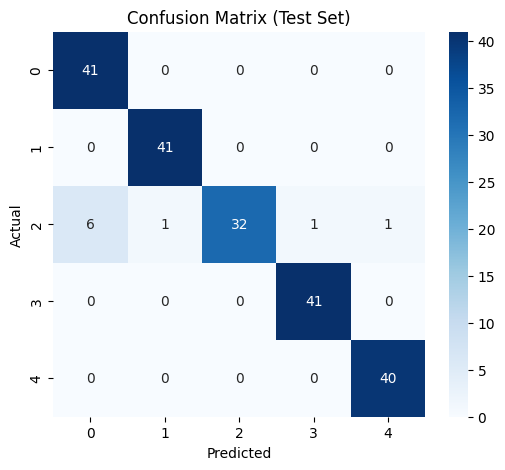

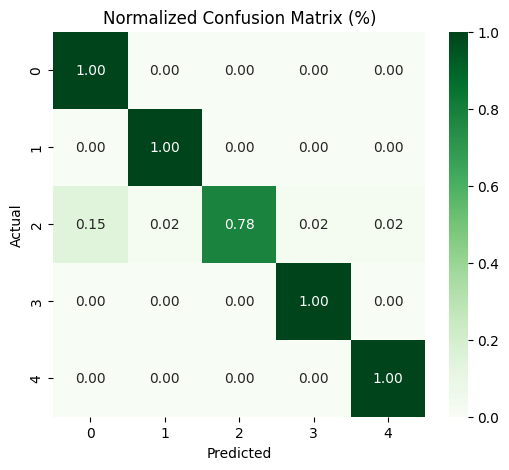


Results saved successfully


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    classification_report,
    confusion_matrix
)

import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import os

# =========================
# MODEL EVALUATION
# =========================
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        labels = labels.to(device)

        # =========================
        # TEST-TIME AUGMENTATION
        # =========================
        out1 = model(images)

        out2 = model(
            torch.flip(
                images,
                dims=[3]
            )
        )

        outputs = (
            out1 + out2
        ) / 2

        preds = torch.argmax(
            outputs,
            1
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

# =========================
# PERFORMANCE METRICS
# =========================
test_acc = accuracy_score(
    all_labels,
    all_preds
)

qwk = cohen_kappa_score(
    all_labels,
    all_preds,
    weights='quadratic'
)

print("\nFINAL TEST RESULTS")

print(f"Accuracy: {test_acc:.4f}")

print(f"QWK: {qwk:.4f}")

# =========================
# CLASSIFICATION REPORT
# =========================
print("\nClassification Report:")

print(
    classification_report(
        all_labels,
        all_preds,
        digits=4
    )
)

# =========================
# CONFUSION MATRICES
# =========================
cm = confusion_matrix(
    all_labels,
    all_preds
)

cm_norm = cm.astype(
    'float'
) / cm.sum(axis=1)[:, np.newaxis]

# =========================
# PLOT SETTINGS
# =========================
plot_configs = [

    (
        cm,
        'd',
        "Blues",
        "Confusion Matrix (Test Set)"
    ),

    (
        cm_norm,
        '.2f',
        "Greens",
        "Normalized Confusion Matrix (%)"
    )
]

# =========================
# VISUALIZATION
# =========================
for matrix, fmt, cmap, title in plot_configs:

    plt.figure(figsize=(6,5))

    sns.heatmap(

        matrix,

        annot=True,

        fmt=fmt,

        cmap=cmap
    )

    plt.title(title)

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

# =========================
# SAVE RESULTS
# =========================
RESULT_PATH = (
    "/content/drive/MyDrive/"
    "DR_New_Results/IDRiD"
)

os.makedirs(
    RESULT_PATH,
    exist_ok=True
)

np.save(
    f"{RESULT_PATH}/confusion_matrix.npy",
    cm
)

print("\nResults saved successfully")

**Final Model Evaluation**


FINAL TEST RESULTS
Accuracy: 0.9608
Precision: 0.9627
Recall: 0.9608
F1 Score: 0.9600
QWK: 0.9724

Classification Report:

              precision    recall  f1-score   support

           0     0.8913    1.0000    0.9425        41
           1     0.9762    1.0000    0.9880        41
           2     0.9714    0.8293    0.8947        41
           3     0.9756    0.9756    0.9756        41
           4     1.0000    1.0000    1.0000        40

    accuracy                         0.9608       204
   macro avg     0.9629    0.9610    0.9602       204
weighted avg     0.9627    0.9608    0.9600       204



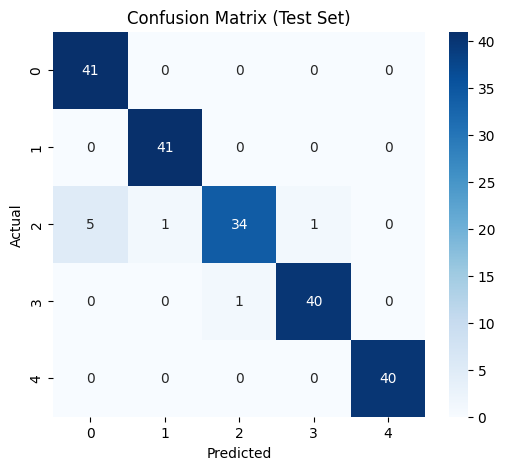

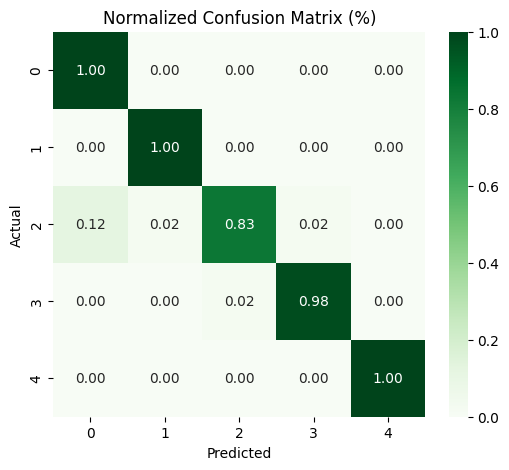


Results saved successfully


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch
import os

# =========================
# LOAD BEST MODEL
# =========================
model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

model.to(device)

model.eval()

# =========================
# TEST PREDICTIONS
# =========================
y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        labels = labels.to(device)

        # =========================
        # TEST-TIME AUGMENTATION
        # =========================
        out1 = model(images)

        out2 = model(
            torch.flip(
                images,
                dims=[3]
            )
        )

        outputs = (
            out1 + out2
        ) / 2

        preds = torch.argmax(
            outputs,
            1
        )

        y_true.extend(
            labels.cpu().numpy()
        )

        y_pred.extend(
            preds.cpu().numpy()
        )

# =========================
# PERFORMANCE METRICS
# =========================
metrics = {

    "Accuracy": accuracy_score(
        y_true,
        y_pred
    ),

    "Precision": precision_score(
        y_true,
        y_pred,
        average='weighted',
        zero_division=0
    ),

    "Recall": recall_score(
        y_true,
        y_pred,
        average='weighted',
        zero_division=0
    ),

    "F1 Score": f1_score(
        y_true,
        y_pred,
        average='weighted',
        zero_division=0
    ),

    "QWK": cohen_kappa_score(
        y_true,
        y_pred,
        weights='quadratic'
    )
}

# =========================
# DISPLAY RESULTS
# =========================
print("\nFINAL TEST RESULTS")

for name, value in metrics.items():

    print(f"{name}: {value:.4f}")

# =========================
# CLASSIFICATION REPORT
# =========================
print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

# =========================
# CONFUSION MATRICES
# =========================
cm = confusion_matrix(
    y_true,
    y_pred
)

cm_norm = cm.astype(
    'float'
) / cm.sum(axis=1)[:, np.newaxis]

# =========================
# MATRIX VISUALIZATION
# =========================
plot_configs = [

    (
        cm,
        "d",
        "Blues",
        "Confusion Matrix (Test Set)"
    ),

    (
        cm_norm,
        ".2f",
        "Greens",
        "Normalized Confusion Matrix (%)"
    )
]

for matrix, fmt, cmap, title in plot_configs:

    plt.figure(figsize=(6,5))

    sns.heatmap(

        matrix,

        annot=True,

        fmt=fmt,

        cmap=cmap
    )

    plt.title(title)

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

# =========================
# SAVE RESULTS
# =========================
save_dir = (
    "/content/drive/MyDrive/"
    "DR_New_Results/IDRiD"
)

os.makedirs(
    save_dir,
    exist_ok=True
)

# Save confusion matrix image
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig(
    os.path.join(
        save_dir,
        "confusion_matrix.png"
    ),
    dpi=300
)

plt.close()

# Save matrix array
np.save(
    os.path.join(
        save_dir,
        "confusion_matrix.npy"
    ),
    cm
)

print("\nResults saved successfully")

Model Evaluation and Result Visualization


 FINAL RESULTS
Accuracy : 0.8824
Precision: 0.8786
Recall   : 0.8824
F1 Score : 0.8790
QWK      : 0.9457


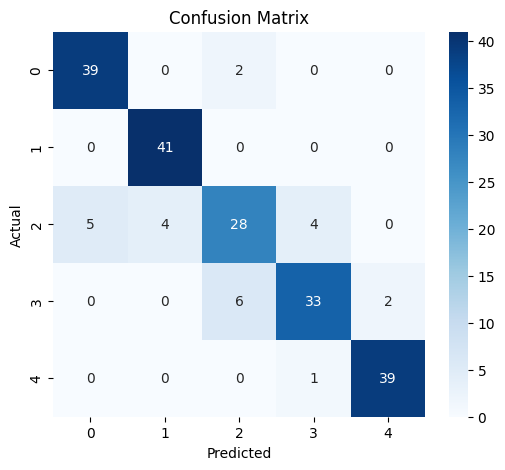

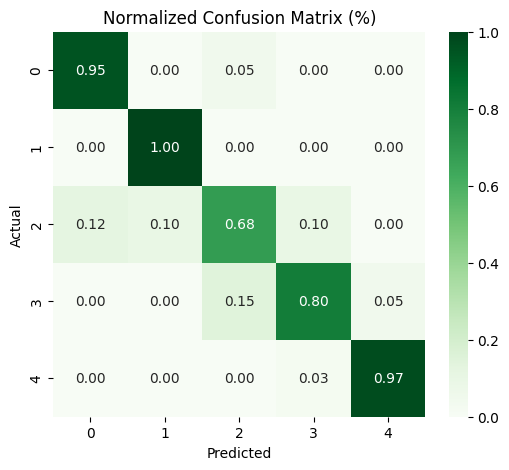


Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.95      0.92        41
           1       0.91      1.00      0.95        41
           2       0.78      0.68      0.73        41
           3       0.87      0.80      0.84        41
           4       0.95      0.97      0.96        40

    accuracy                           0.88       204
   macro avg       0.88      0.88      0.88       204
weighted avg       0.88      0.88      0.88       204


 ALL RESULTS SAVED IN: /content/drive/MyDrive/DR_New_Results/IDRiD


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    classification_report,
    confusion_matrix
)

# =========================
# RESULTS DIRECTORY
# =========================
RESULTS_PATH = (
    "/content/drive/MyDrive/"
    "DR_New_Results/IDRiD"
)

os.makedirs(
    RESULTS_PATH,
    exist_ok=True
)

# =========================
# LOAD BEST MODEL
# =========================
model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

model.to(device)

model.eval()

# =========================
# TEST PREDICTIONS
# =========================
y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        labels = labels.to(device)

        # =========================
        # TEST-TIME AUGMENTATION
        # =========================
        out1 = model(images)

        out2 = model(
            torch.flip(
                images,
                dims=[3]
            )
        )

        outputs = (
            out1 + out2
        ) / 2

        preds = torch.argmax(
            outputs,
            1
        )

        y_true.extend(
            labels.cpu().numpy()
        )

        y_pred.extend(
            preds.cpu().numpy()
        )

# =========================
# PERFORMANCE METRICS
# =========================
metrics = {

    "Accuracy": accuracy_score(
        y_true,
        y_pred
    ),

    "Precision": precision_score(
        y_true,
        y_pred,
        average='weighted',
        zero_division=0
    ),

    "Recall": recall_score(
        y_true,
        y_pred,
        average='weighted',
        zero_division=0
    ),

    "F1 Score": f1_score(
        y_true,
        y_pred,
        average='weighted',
        zero_division=0
    ),

    "QWK": cohen_kappa_score(
        y_true,
        y_pred,
        weights='quadratic'
    )
}

print("\nFINAL RESULTS")

for name, value in metrics.items():

    print(f"{name}: {value:.4f}")

# =========================
# CLASSIFICATION REPORT
# =========================
report = classification_report(
    y_true,
    y_pred,
    zero_division=0
)

print("\nClassification Report:\n")

print(report)

with open(
    os.path.join(
        RESULTS_PATH,
        "classification_report.txt"
    ),
    "w"
) as f:

    f.write(report)

# =========================
# CONFUSION MATRICES
# =========================
cm = confusion_matrix(
    y_true,
    y_pred
)

cm_norm = cm.astype(
    float
) / cm.sum(axis=1)[:, np.newaxis]

# =========================
# MATRIX VISUALIZATION
# =========================
matrix_configs = [

    (
        cm,
        'd',
        "Blues",
        "Confusion Matrix",
        "confusion_matrix.png"
    ),

    (
        cm_norm,
        ".2f",
        "Greens",
        "Normalized Confusion Matrix (%)",
        "confusion_matrix_normalized.png"
    )
]

for matrix, fmt, cmap, title, filename in matrix_configs:

    plt.figure(figsize=(6,5))

    sns.heatmap(

        matrix,

        annot=True,

        fmt=fmt,

        cmap=cmap
    )

    plt.title(title)

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.savefig(

        os.path.join(
            RESULTS_PATH,
            filename
        ),

        dpi=300
    )

    plt.show()

# =========================
# METRICS TABLE
# =========================
metrics_data = [

    [key, f"{value:.4f}"]

    for key, value in metrics.items()
]

fig, ax = plt.subplots(figsize=(4,2))

ax.axis('off')

table = ax.table(

    cellText=metrics_data,

    colLabels=["Metric", "Value"],

    loc='center'
)

table.auto_set_font_size(False)

table.set_fontsize(10)

table.scale(1, 1.5)

plt.savefig(

    os.path.join(
        RESULTS_PATH,
        "metrics_table.png"
    ),

    dpi=300
)

plt.close()

# =========================
# DISTRIBUTION PLOTS
# =========================
distribution_configs = [

    (
        [y_pred],
        ["Predicted"],
        "Prediction Distribution",
        "prediction_distribution.png"
    ),

    (
        [y_true, y_pred],
        ["True", "Predicted"],
        "True vs Predicted",
        "true_vs_pred.png"
    )
]

for data_list, labels_list, title, filename in distribution_configs:

    plt.figure(figsize=(6,4))

    for data, label in zip(data_list, labels_list):

        plt.hist(

            data,

            bins=np.arange(6)-0.5,

            alpha=0.6,

            rwidth=0.7,

            label=label
        )

    plt.xticks(range(5))

    plt.title(title)

    if len(labels_list) > 1:

        plt.legend()

    plt.savefig(

        os.path.join(
            RESULTS_PATH,
            filename
        ),

        dpi=300
    )

    plt.close()

# =========================
# CLASS-WISE ACCURACY
# =========================
class_acc = (
    cm.diagonal()
    / cm.sum(axis=1)
)

plt.figure(figsize=(6,4))

plt.bar(
    range(len(class_acc)),
    class_acc
)

plt.xticks(range(5))

plt.ylim(0,1)

plt.title("Class-wise Accuracy")

plt.savefig(

    os.path.join(
        RESULTS_PATH,
        "classwise_accuracy.png"
    ),

    dpi=300
)

plt.close()

# =========================
# SAVE MATRIX ARRAY
# =========================
np.save(

    os.path.join(
        RESULTS_PATH,
        "confusion_matrix.npy"
    ),

    cm
)

print(
    f"\nAll results saved in: "
    f"{RESULTS_PATH}"
)

**Ablation Study**

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import cohen_kappa_score
import os

# =========================
# DEVICE CONFIGURATION
# =========================
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

# =========================
# CLEAN VALIDATION DATA
# =========================
val_df = val_df.drop_duplicates(
    subset=["image_path"]
).reset_index(drop=True)

# =========================
# REBUILD DATASETS
# =========================
train_dataset = DRDataset(
    train_df,
    transform=train_transform
)

val_dataset = DRDataset(
    val_df,
    transform=val_transform
)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))

# =========================
# DATALOADER SETTINGS
# =========================
loader_kwargs = dict(

    # 🔥 Reduced for DenseNet201
    batch_size=8,

    num_workers=2,

    pin_memory=True
)

# =========================
# DATALOADERS
# =========================
train_loader = DataLoader(

    train_dataset,

    shuffle=True,

    drop_last=True,

    **loader_kwargs
)

val_loader = DataLoader(

    val_dataset,

    shuffle=False,

    **loader_kwargs
)

# =========================
# MODEL INITIALIZATION
# =========================
model = DRModel(
    num_classes=5
).to(device)

# =========================
# LOSS AND OPTIMIZER
# =========================
optimizer = optim.AdamW(

    model.parameters(),

    # 🔥 Better for DenseNet201
    lr=5e-5,

    weight_decay=1e-4
)

criterion = nn.CrossEntropyLoss(

    # 🔥 Better generalization
    label_smoothing=0.1
)

# =========================
# LEARNING RATE SCHEDULER
# =========================
num_epochs = 10

scheduler = optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=num_epochs
)

# =========================
# SAVE PATH
# =========================
RESULT_PATH = (
    "/content/drive/MyDrive/"
    "DR_New_Results/IDRiD"
)

os.makedirs(

    RESULT_PATH,

    exist_ok=True
)

best_model_path = os.path.join(

    RESULT_PATH,

    "best_model.pth"
)

# =========================
# TRAINING LOOP
# =========================
best_qwk = 0

for epoch in range(num_epochs):

    # =========================
    # TRAINING
    # =========================
    model.train()

    train_loss = 0

    for images, labels in train_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs = model(images)

        outputs = torch.clamp(
            outputs,
            -10,
            10
        )

        loss = criterion(
            outputs,
            labels
        )

        if not torch.isfinite(loss):

            continue

        loss.backward()

        # =========================
        # GRADIENT CLIPPING
        # =========================
        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            1.0
        )

        optimizer.step()

        train_loss += loss.item()

    # =========================
    # VALIDATION
    # =========================
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            # =========================
            # TEST-TIME AUGMENTATION
            # =========================
            out1 = model(images)

            out2 = model(
                torch.flip(
                    images,
                    dims=[3]
                )
            )

            outputs = (
                out1 + out2
            ) / 2

            preds = torch.argmax(
                outputs,
                1
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_labels.extend(
                labels.numpy()
            )

    # =========================
    # COMPUTE QWK
    # =========================
    qwk = cohen_kappa_score(

        all_labels,

        all_preds,

        weights='quadratic'
    )

    scheduler.step()

    # =========================
    # DISPLAY RESULTS
    # =========================
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    print(f"Train Loss: {train_loss:.4f}")

    print(f"QWK: {qwk:.4f}")

    # =========================
    # SAVE BEST MODEL
    # =========================
    if qwk > best_qwk:

        best_qwk = qwk

        torch.save(

            model.state_dict(),

            best_model_path
        )

        print("Best model saved")

# =========================
# FINAL RESULT
# =========================
print(f"\nFinal Best QWK: {best_qwk:.4f}")

Device: cuda
Valid images: 1632
Valid images: 187
Train: 1632
Val: 187

Epoch 1/10
Train Loss: 260.5745
QWK: 0.8436
Best model saved

Epoch 2/10
Train Loss: 180.7553
QWK: 0.8787
Best model saved

Epoch 3/10
Train Loss: 143.9902
QWK: 0.9621
Best model saved

Epoch 4/10
Train Loss: 124.2873
QWK: 0.9564

Epoch 5/10
Train Loss: 115.9667
QWK: 0.9673
Best model saved

Epoch 6/10
Train Loss: 108.4354
QWK: 0.9737
Best model saved

Epoch 7/10
Train Loss: 102.4427
QWK: 0.9737
Best model saved

Epoch 8/10
Train Loss: 94.9616
QWK: 0.9789
Best model saved

Epoch 9/10
Train Loss: 96.4477
QWK: 0.9802
Best model saved

Epoch 10/10
Train Loss: 93.1112
QWK: 0.9802

Final Best QWK: 0.9802


In [24]:
# ==========================================
# ABLATION STUDY (DENSENET201)
# ==========================================

import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import timm
import matplotlib.pyplot as plt

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    cohen_kappa_score
)

# =========================
# DEVICE
# =========================
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using:", device)

# =========================
# SAVE PATH
# =========================
SAVE_PATH = (
    "/content/drive/MyDrive/"
    "DR_New_Results/IDRiD/"
    "ablation_densenet201"
)

os.makedirs(
    SAVE_PATH,
    exist_ok=True
)

# =========================
# LOAD DATA
# =========================
DATA_PATH = (
    "/content/drive/MyDrive/"
    "Dataset/IDRiD/Train"
)

df = pd.read_csv(
    os.path.join(
        DATA_PATH,
        "annotations.csv"
    )
)

df.rename(
    columns={
        "Retinopathy grade": "label"
    },
    inplace=True
)

# =========================
# FIND IMAGE PATH
# =========================
def find_image_path(name):

    name = str(name).strip()

    name = os.path.splitext(name)[0]

    for ext in [
        ".jpg",
        ".png",
        ".jpeg"
    ]:

        full_path = os.path.join(
            DATA_PATH,
            "images",
            name + ext
        )

        if os.path.exists(full_path):

            return full_path

    return None

df["image_path"] = df[
    "Image name"
].apply(find_image_path)

# =========================
# REMOVE MISSING
# =========================
df = df.dropna(
    subset=["image_path"]
).reset_index(drop=True)

print(
    "Total samples:",
    len(df)
)

# =========================
# TRAIN / VAL SPLIT
# =========================
train_df, val_df = train_test_split(

    df,

    test_size=0.2,

    stratify=df["label"],

    random_state=42
)

# =========================
# DATASET
# =========================
class DRDataset(Dataset):

    def __init__(

        self,

        df,

        transform=None
    ):

        self.df = df.reset_index(
            drop=True
        )

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        img_path = self.df.loc[
            idx,
            "image_path"
        ]

        label = self.df.loc[
            idx,
            "label"
        ]

        try:

            img = Image.open(
                img_path
            ).convert("RGB")

        except Exception:

            img = Image.new(
                "RGB",
                (320,320)
            )

        if self.transform:

            img = self.transform(img)

        return img, label

# =========================
# TRANSFORMS
# =========================
transform = transforms.Compose([

    transforms.Resize((320,320)),

    transforms.ToTensor(),

    transforms.Normalize(

        [0.485,0.456,0.406],

        [0.229,0.224,0.225]
    )
])

# =========================
# DATASETS
# =========================
train_dataset = DRDataset(
    train_df,
    transform
)

val_dataset = DRDataset(
    val_df,
    transform
)

# =========================
# DATALOADERS
# =========================
train_loader = DataLoader(

    train_dataset,

    batch_size=8,

    shuffle=True,

    num_workers=2,

    pin_memory=True,

    drop_last=True
)

val_loader = DataLoader(

    val_dataset,

    batch_size=8,

    shuffle=False,

    num_workers=2,

    pin_memory=True
)

# =========================
# MODEL
# =========================
class DRModel(nn.Module):

    def __init__(

        self,

        use_cross=False,

        use_region=False
    ):

        super().__init__()

        # =========================
        # DENSENET201 BACKBONE
        # =========================
        self.backbone = timm.create_model(

            "densenet201",

            pretrained=True,

            num_classes=0
        )

        dim = self.backbone.num_features

        # =========================
        # FLAGS
        # =========================
        self.use_cross = use_cross

        self.use_region = use_region

        # =========================
        # CROSS PATCH
        # =========================
        self.cross = nn.Conv2d(

            dim,

            dim,

            kernel_size=1
        )

        # =========================
        # REGION ATTENTION
        # =========================
        self.region = nn.Sequential(

            nn.Conv2d(

                dim,

                1,

                kernel_size=3,

                padding=1
            ),

            nn.Sigmoid()
        )

        # =========================
        # POOLING
        # =========================
        self.pool = nn.AdaptiveAvgPool2d(1)

        # =========================
        # CLASSIFIER
        # =========================
        self.fc = nn.Linear(
            dim,
            5
        )

    def forward(self, x):

        # =========================
        # FEATURE EXTRACTION
        # =========================
        x = self.backbone.forward_features(x)

        # =========================
        # CROSS PATCH
        # =========================
        if self.use_cross:

            x = x + self.cross(x)

        # =========================
        # REGION ATTENTION
        # =========================
        if self.use_region:

            x = x * self.region(x)

        # =========================
        # GLOBAL POOLING
        # =========================
        x = self.pool(x).flatten(1)

        # =========================
        # CLASSIFICATION
        # =========================
        return self.fc(x)

# =========================
# PARAMETER COUNT
# =========================
def count_params(model):

    return sum(

        p.numel()

        for p in model.parameters()

        if p.requires_grad
    )

# =========================
# TRAIN FUNCTION
# =========================
def train_model(

    config,

    name,

    epochs=10
):

    model = DRModel(
        **config
    ).to(device)

    optimizer = optim.AdamW(

        model.parameters(),

        lr=5e-5,

        weight_decay=1e-4
    )

    scheduler = (
        optim.lr_scheduler.CosineAnnealingLR(

            optimizer,

            T_max=epochs
        )
    )

    criterion = nn.CrossEntropyLoss(
        label_smoothing=0.1
    )

    start = time.time()

    # =========================
    # TRAINING
    # =========================
    for epoch in range(epochs):

        model.train()

        for images, labels in train_loader:

            images = images.to(device)

            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            outputs = torch.clamp(
                outputs,
                -10,
                10
            )

            loss = criterion(
                outputs,
                labels
            )

            if not torch.isfinite(loss):

                continue

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0
            )

            optimizer.step()

        scheduler.step()

        print(
            f"{name} Epoch "
            f"{epoch+1}/{epochs}"
        )

    # =========================
    # VALIDATION
    # =========================
    model.eval()

    preds = []

    true = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            outputs = model(images)

            p = torch.argmax(
                outputs,
                1
            )

            preds.extend(
                p.cpu().numpy()
            )

            true.extend(
                labels.numpy()
            )

    end = time.time()

    # =========================
    # METRICS
    # =========================
    acc = accuracy_score(
        true,
        preds
    )

    f1 = f1_score(
        true,
        preds,
        average='weighted'
    )

    qwk = cohen_kappa_score(
        true,
        preds,
        weights='quadratic'
    )

    params = round(
        count_params(model) / 1e6,
        2
    )

    return (

        acc,

        f1,

        qwk,

        params,

        round(end-start,2)
    )

# =========================
# EXPERIMENTS
# =========================
experiments = {

    "Baseline": {

        "use_cross": False,

        "use_region": False
    },

    "Baseline + CrossPatch": {

        "use_cross": True,

        "use_region": False
    },

    "Baseline + RegionAttention": {

        "use_cross": False,

        "use_region": True
    },

    "Baseline + CrossPatch + Region": {

        "use_cross": True,

        "use_region": True
    }
}

results = []

# =========================
# RUN EXPERIMENTS
# =========================
for name, config in experiments.items():

    print(f"\nRunning {name}")

    acc, f1, qwk, params, t = train_model(

        config,

        name,

        epochs=10
    )

    results.append({

        "Model": name,

        "Accuracy": round(acc,4),

        "F1-Score": round(f1,4),

        "QWK": round(qwk,4),

        "Params (M)": params,

        "Time (s)": t
    })

# =========================
# RESULTS TABLE
# =========================
df_results = pd.DataFrame(results)

print("\nFINAL RESULTS\n")

print(df_results)

# =========================
# SAVE CSV
# =========================
csv_path = os.path.join(
    SAVE_PATH,
    "ablation_results.csv"
)

df_results.to_csv(
    csv_path,
    index=False
)

# =========================
# SAVE TABLE IMAGE
# =========================
fig, ax = plt.subplots(
    figsize=(10,3)
)

ax.axis('off')

table = ax.table(

    cellText=df_results.values,

    colLabels=df_results.columns,

    loc='center'
)

table.auto_set_font_size(False)

table.set_fontsize(10)

table.scale(1,1.5)

plt.savefig(

    os.path.join(
        SAVE_PATH,
        "ablation_table.png"
    ),

    dpi=300,

    bbox_inches='tight'
)

plt.close()

# =========================
# SAVE QWK PLOT
# =========================
plt.figure(figsize=(7,4))

plt.bar(
    df_results["Model"],
    df_results["QWK"]
)

plt.ylabel("QWK")

plt.title(
    "DenseNet201 Ablation Study"
)

plt.xticks(rotation=10)

plt.savefig(

    os.path.join(
        SAVE_PATH,
        "ablation_plot.png"
    ),

    dpi=300,

    bbox_inches='tight'
)

plt.close()

print("\nAll results saved in:")
print(SAVE_PATH)

Using: cuda
Total samples: 1239

Running Baseline


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/81.1M [00:00<?, ?B/s]

Baseline Epoch 1/10
Baseline Epoch 2/10
Baseline Epoch 3/10
Baseline Epoch 4/10
Baseline Epoch 5/10
Baseline Epoch 6/10
Baseline Epoch 7/10
Baseline Epoch 8/10
Baseline Epoch 9/10
Baseline Epoch 10/10

Running Baseline + CrossPatch


Baseline + CrossPatch Epoch 1/10
Baseline + CrossPatch Epoch 2/10
Baseline + CrossPatch Epoch 3/10
Baseline + CrossPatch Epoch 4/10
Baseline + CrossPatch Epoch 5/10
Baseline + CrossPatch Epoch 6/10
Baseline + CrossPatch Epoch 7/10
Baseline + CrossPatch Epoch 8/10
Baseline + CrossPatch Epoch 9/10
Baseline + CrossPatch Epoch 10/10

Running Baseline + RegionAttention
Baseline + RegionAttention Epoch 1/10
Baseline + RegionAttention Epoch 2/10
Baseline + RegionAttention Epoch 3/10
Baseline + RegionAttention Epoch 4/10
Baseline + RegionAttention Epoch 5/10
Baseline + RegionAttention Epoch 6/10
Baseline + RegionAttention Epoch 7/10
Baseline + RegionAttention Epoch 8/10
Baseline + RegionAttention Epoch 9/10
Baseline + RegionAttention Epoch 10/10

Running Baseline + CrossPatch + Region
Baseline + CrossPatch + Region Epoch 1/10
Baseline + CrossPatch + Region Epoch 2/10
Baseline + CrossPatch + Region Epoch 3/10
Baseline + CrossPatch + Region Epoch 4/10
Baseline + CrossPatch + Region Epoch 5/10
Ba